<a href="https://colab.research.google.com/github/poojaashree2007/Car_Price_Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully

First 5 Rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Last 5 Rows:
    Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
296     city  2016           9.50           11.6       33988    Diesel   
297     brio  2015           4.00            5.9       60000    Petrol   
298     city  2009           3.35           11.0       87934    Pe

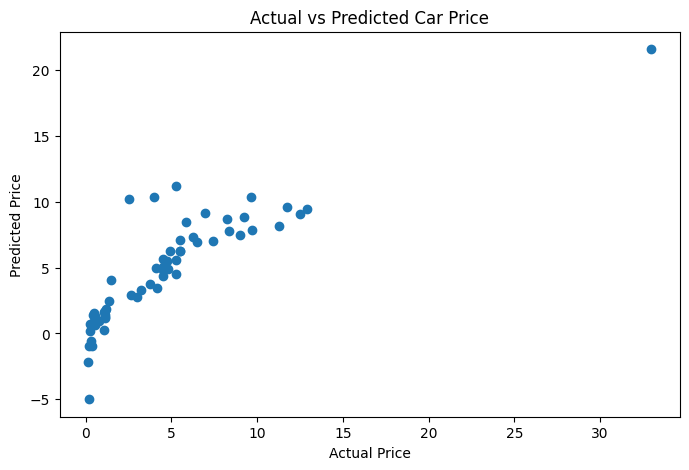

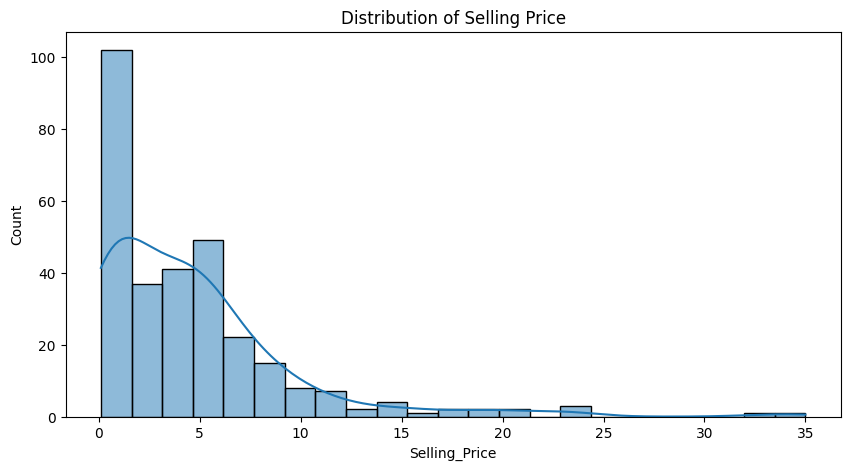

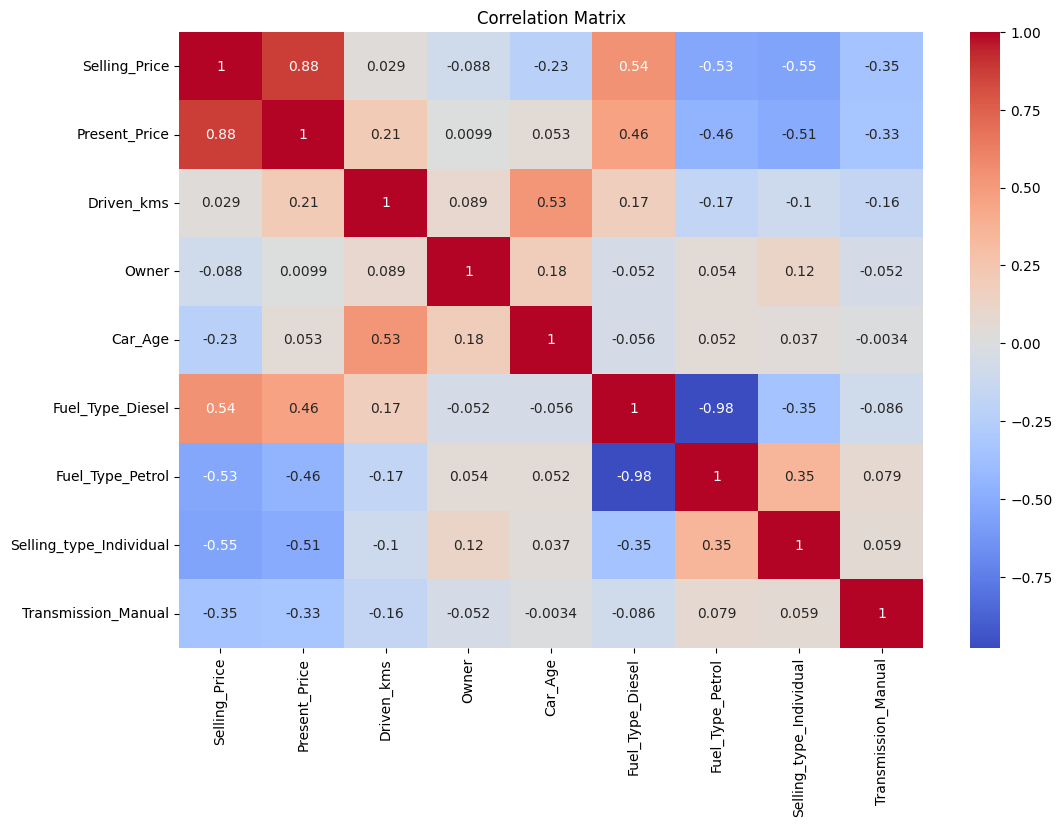


Feature Importance
                   Feature  Coefficient
4         Fuel_Type_Diesel     2.142391
5         Fuel_Type_Petrol     0.692516
2                    Owner     0.640144
0            Present_Price     0.437119
1               Driven_kms    -0.000011
3                  Car_Age    -0.330031
6  Selling_type_Individual    -1.302291
7      Transmission_Manual    -1.573425

Complete Dataset
                      Car_Name  Selling_Price  Present_Price  Driven_kms  \
0                         ritz           3.35          5.590       27000   
1                          sx4           4.75          9.540       43000   
2                         ciaz           7.25          9.850        6900   
3                      wagon r           2.85          4.150        5200   
4                        swift           4.60          6.870       42450   
5                vitara brezza           9.25          9.830        2071   
6                         ciaz           6.75          8.120       187

In [13]:
# ==========================================
# TASK 3: CAR PRICE PREDICTION
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("car data.csv")

print("Dataset Loaded Successfully")
print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nTotal Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

# ==========================================
# DATASET INFORMATION
# ==========================================

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# DATA CLEANING
# ==========================================

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# ==========================================
# FEATURE ENGINEERING
# ==========================================

current_year = 2025
df["Car_Age"] = current_year - df["Year"]

df.drop("Year", axis=1, inplace=True)

# ==========================================
# ENCODE CATEGORICAL VARIABLES
# ==========================================

categorical_columns = ["Fuel_Type", "Selling_type", "Transmission"]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

# Convert True/False columns to 0/1
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

print("\nDataset After Encoding")
print(df.head())

# ==========================================
# DEFINE FEATURES AND TARGET
# ==========================================

X = df.drop(["Selling_Price", "Car_Name"], axis=1)

y = df["Selling_Price"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Trained Successfully")

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted Prices")
print(results.head(20))

# ==========================================
# VISUALIZATION 1
# ==========================================

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

# ==========================================
# VISUALIZATION 2
# ==========================================

plt.figure(figsize=(10,5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

# ==========================================
# VISUALIZATION 3
# ==========================================

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nFeature Importance")
print(importance)

# ==========================================
# SHOW ALL ROWS OF CSV
# ==========================================

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("\nComplete Dataset")
print(df)

# ==========================================
# SAMPLE PREDICTION
# ==========================================

sample_car = X.iloc[[0]]

predicted_price = model.predict(sample_car)

print("\nPredicted Price for First Car:")
print(predicted_price[0])

# ==========================================
# SAVE PREDICTIONS
# ==========================================

results.to_csv("Car_Price_Predictions.csv", index=False)

print("\nPrediction file saved successfully.")